# Import Libraries

In [2]:
import os
import json
import csv
import random
from pathlib import Path

# Data Science & Visualization
import numpy as np
import pandas as pd  # Often useful with CSVs
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Computer Vision
import cv2

# Scikit-Learn (Metrics & Preprocessing)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, confusion_matrix, 
    classification_report, mean_absolute_error, 
    mean_squared_error, r2_score
)

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model, regularizers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Flatten, Concatenate, Layer

# Data Prepration

## Data Loading

In [3]:
def get_anemia_label(age, gender, hb):
    """
    WHO 4-class anemia classification.
    gender : 1=Male, 0=Female
    age    : in years
    hb     : hemoglobin in g/dL
    Returns: 0=Non-Anemic, 1=Mild, 2=Moderate, 3=Severe
             -1=Not applicable (ages 5-14 and 65+)
    """
    if age < 5:                          # < 59 months (~5 years)
        if   hb >= 11.0: return 0        # Non-Anemic
        elif hb >= 10.0: return 1        # Mild
        elif hb >= 7.0:  return 2        # Moderate
        else:            return 3        # Severe

    elif 15 <= age <= 65:
        if gender == 0:                  # Non-Pregnant Women
            if   hb >= 12.0: return 0
            elif hb >= 11.0: return 1
            elif hb >= 8.0:  return 2
            else:            return 3
        else:                            # Men
            if   hb >= 13.0: return 0
            elif hb >= 11.0: return 1
            elif hb >= 8.0:  return 2
            else:            return 3

    else:
        return -1                        # Ages 5-14 and 65+ — exclude from dataset

In [4]:
Dataset_path = "Data" 
IMG_SIZE = 224

In [5]:
def load_dataset(Dataset_path):
    X_palm, X_nail, X_meta = [], [], []
    y_hb                    = []
    subject_ids             = []

    root     = Path(Dataset_path)
    subjects = [p for p in root.iterdir() if p.is_dir()]

    for s in subjects:
        json_path = s / "info.json"
        if not json_path.exists():
            continue
        with open(json_path, "r") as f:
            info = json.load(f)

        age    = info["age"]
        gender = 1 if info["gender"] == "Male" else 0
        hb     = float(info["HB_Level"])

        # Palm ROI
        palm_path = s / "Palm_ROI" / "frame_03.jpg"
        if not palm_path.exists():
            continue
        palm_img = cv2.imread(str(palm_path))
        if palm_img is None:
            continue
        palm_img = cv2.cvtColor(palm_img, cv2.COLOR_BGR2RGB)
        palm_img = cv2.resize(palm_img, (IMG_SIZE, IMG_SIZE))
        palm_img = palm_img / 255.0

        # Nail ROI + background removal
        nail_path = s / "nail_roi.jpg"
        if not nail_path.exists():
            continue
        nail_img = cv2.imread(str(nail_path))
        if nail_img is None:
            continue
        
        nail_img = cv2.cvtColor(nail_img, cv2.COLOR_BGR2RGB)
        nail_img = cv2.resize(nail_img, (IMG_SIZE, IMG_SIZE))
        nail_img = nail_img / 255.0

        X_palm.append(palm_img)
        X_nail.append(nail_img)
        X_meta.append([age, gender])
        y_hb.append(hb)
        subject_ids.append(s.name)

    return (
        np.array(X_palm,  dtype=np.float32),
        np.array(X_nail,  dtype=np.float32),
        np.array(X_meta,  dtype=np.float32),
        np.array(y_hb,    dtype=np.float32),
        np.array(subject_ids)
    )

In [6]:
X_palm, X_nail, X_meta, y_hb, subject_ids = load_dataset(Dataset_path)

In [7]:
X_meta_original = X_meta.copy()

In [8]:
X_meta[:, 0] = (X_meta[:, 0] - X_meta[:, 0].mean()) / X_meta[:, 0].std()

In [9]:
y_label = np.array([
    get_anemia_label(X_meta_original[i, 0], X_meta_original[i, 1], y_hb[i])
    for i in range(len(subject_ids))
], dtype=np.int32)

print(f"Total patients : {len(subject_ids)}")
print(f"Non-Anemic (0) : {sum(y_label == 0)}")
print(f"Mild (1)       : {sum(y_label == 1)}")
print(f"Moderate (2)   : {sum(y_label == 2)}")
print(f"Severe (3)     : {sum(y_label == 3)}")
print(f"Excluded (-1)  : {sum(y_label == -1)}")

Total patients : 527
Non-Anemic (0) : 263
Mild (1)       : 192
Moderate (2)   : 72
Severe (3)     : 0
Excluded (-1)  : 0


## Data Split

In [10]:
unique_subjects = np.unique(subject_ids)
unique_labels = np.array([
    0 if y_hb[subject_ids == s][0] >= 12.0 else 1 
    for s in unique_subjects
])

train_subj, temp_subj = train_test_split(
    unique_subjects, test_size=0.30, random_state=42, stratify=unique_labels
)
temp_labels = np.array([
    0 if y_hb[subject_ids == s][0] >= 12.0 else 1 
    for s in temp_subj
])
val_subj, test_subj = train_test_split(
    temp_subj, test_size=0.50, random_state=42, stratify=temp_labels
)

train_idx = np.where(np.isin(subject_ids, train_subj))[0]
val_idx   = np.where(np.isin(subject_ids, val_subj))[0]
test_idx  = np.where(np.isin(subject_ids, test_subj))[0]

X_palm_train, X_palm_val, X_palm_test = X_palm[train_idx], X_palm[val_idx], X_palm[test_idx]
X_nail_train, X_nail_val, X_nail_test = X_nail[train_idx], X_nail[val_idx], X_nail[test_idx]
X_meta_train, X_meta_val, X_meta_test = X_meta[train_idx], X_meta[val_idx], X_meta[test_idx]
y_hb_train, y_hb_val, y_hb_test       = y_hb[train_idx],   y_hb[val_idx],   y_hb[test_idx]

print(f"\nTrain : {len(train_subj)} patients | HB range: {y_hb_train.min():.1f} — {y_hb_train.max():.1f}")
print(f"Val   : {len(val_subj)}   patients | HB range: {y_hb_val.min():.1f} — {y_hb_val.max():.1f}")
print(f"Test  : {len(test_subj)}  patients | HB range: {y_hb_test.min():.1f} — {y_hb_test.max():.1f}")


Train : 368 patients | HB range: 8.6 — 17.0
Val   : 79   patients | HB range: 9.6 — 16.4
Test  : 80  patients | HB range: 10.3 — 15.9


## Data Augmentation

In [11]:
from Augmentation import augment_training_set, augment_image

In [12]:
print("\nBefore Augmentation:")
print(f"  Train size  : {len(y_hb_train)}")

X_palm_train, X_nail_train, X_meta_train, y_hb_train = augment_training_set(X_palm_train, X_nail_train, X_meta_train, y_hb_train ) # pass y_hb instead of y_label)

print(f"\nAfter Augmentation (1 original + 4 fixed augmentations):")
print(f"  Train size  : {len(y_hb_train)}")
print(f"Val  size     : {len(y_hb_val)}")
print(f"Test size     : {len(y_hb_test)}")


Before Augmentation:
  Train size  : 368

After Augmentation (1 original + 4 fixed augmentations):
  Train size  : 1840
Val  size     : 79
Test size     : 80


# Models - Experimentation

In [13]:
import importlib
import Backbones, Attention, Build

importlib.reload(Backbones)
importlib.reload(Attention)
importlib.reload(Build)

from Build import build_models

In [14]:
# Regression Tasks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=10,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        patience=5,
        mode="min",
        factor=0.5,
        min_lr=1e-6
    )
]

In [15]:
def evaluate_regression_model(name, model, history):
    val_scores  = model.evaluate([X_palm_val,  X_nail_val,  X_meta_val],  y_hb_val,  verbose=0)
    test_scores = model.evaluate([X_palm_test, X_nail_test, X_meta_test], y_hb_test, verbose=0)

    print(f"{name}")
    print(f"{'Metric':<20} {'Validation':>12} {'Test':>10}")
    print(f"{'Loss (MSE)':<20} {val_scores[0]:>12.4f} {test_scores[0]:>10.4f}")
    print(f"{'MAE':<20} {val_scores[1]:>12.4f} {test_scores[1]:>10.4f}")
    print(f"{'RMSE':<20} {val_scores[2]:>12.4f} {test_scores[2]:>10.4f}")

    y_hb_pred = model.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).ravel()
    r2        = r2_score(y_hb_test, y_hb_pred)
    print(f"{'R²':<20} {'':>12} {r2:>10.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(name, fontsize=14, fontweight="bold")

    # Plot 1 - MAE curve
    axes[0].plot(history.history["val_mae"], label="val_mae")
    axes[0].plot(history.history["mae"],     label="train_mae")
    axes[0].set_title("MAE Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MAE (g/dL)")
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2 - Loss curve
    axes[1].plot(history.history["val_loss"], label="val_loss")
    axes[1].plot(history.history["loss"],     label="train_loss")
    axes[1].set_title("Loss Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MSE")
    axes[1].legend()
    axes[1].grid(True)

    # Plot 3 - Predicted vs Actual HB scatter
    axes[2].scatter(y_hb_test, y_hb_pred, alpha=0.6, color="steelblue")
    axes[2].plot([y_hb_test.min(), y_hb_test.max()],
                 [y_hb_test.min(), y_hb_test.max()],
                 "r--", lw=2, label="Perfect prediction")
    axes[2].set_title(f"Predicted vs Actual HB\n(R²={r2:.3f})")
    axes[2].set_xlabel("Actual HB (g/dL)")
    axes[2].set_ylabel("Predicted HB (g/dL)")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

## CNN_1

In [20]:
model_1_REG = build_models(backbone="cnn1",mode="regression")

In [21]:
model_1_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_1_REG = model_1_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - loss: 29.5723 - mae: 4.2101 - rmse: 5.4324 - val_loss: 76.2407 - val_mae: 8.6109 - val_rmse: 8.7281 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - loss: 8.4461 - mae: 2.3190 - rmse: 2.8956 - val_loss: 83.2361 - val_mae: 9.0203 - val_rmse: 9.1200 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - loss: 7.1925 - mae: 2.1123 - rmse: 2.6705 - val_loss: 73.7150 - val_mae: 8.4916 - val_rmse: 8.5822 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - loss: 6.5882 - mae: 2.0334 - rmse: 2.5548 - val_loss: 70.9934 - val_mae: 8.3434 - val_rmse: 8.4221 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - loss: 5.7957 - mae: 1.9112 - rmse: 2.3948 - val_loss: 66.6944 - val_mae: 8.0841 - val_rmse: 8.1629 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - loss: 5.7986 - mae: 1.9033 - rmse: 2.395

CNN
Metric                 Validation       Test
Loss (MSE)                 1.1610     1.0272
MAE                        0.8441     0.8195
RMSE                       1.0493     0.9835
R²                                    0.4736


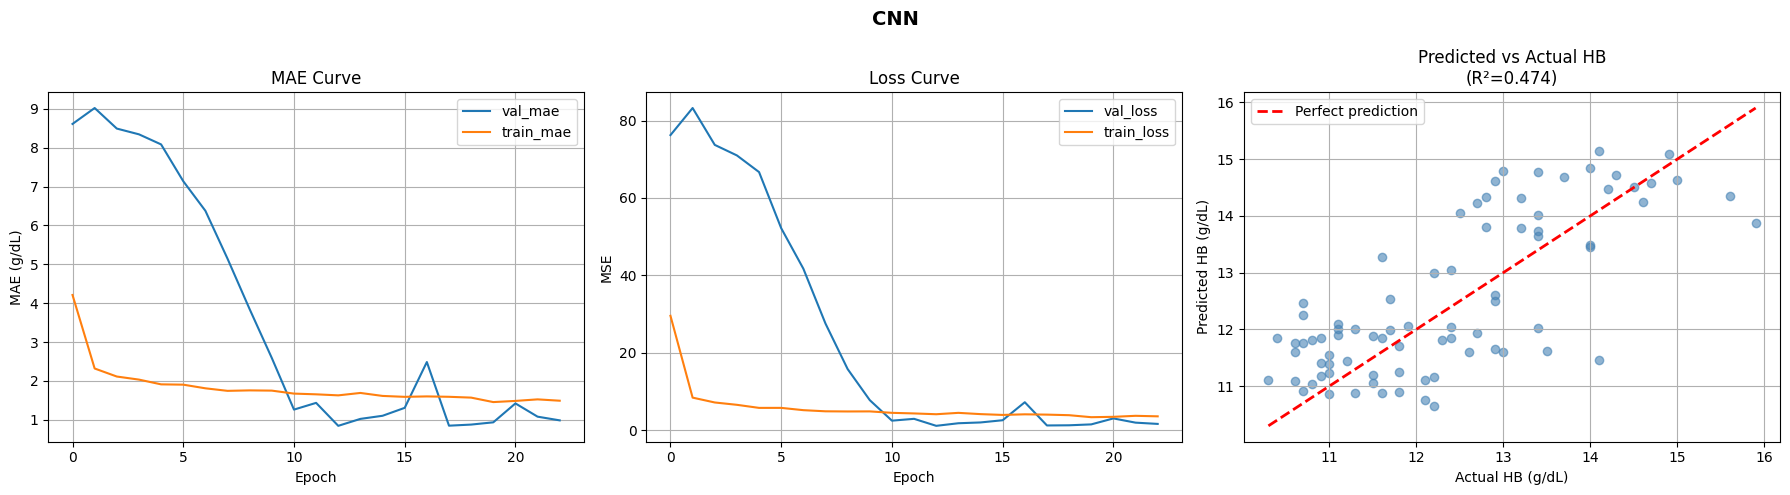

In [22]:
evaluate_regression_model("CNN", model_1_REG, history_1_REG)

## CNN2

In [19]:
model_2_REG = build_models(backbone="cnn2",mode="regression")

In [ ]:
model_2_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_2_REG = model_2_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 181s 3s/step - loss: 51.5746 - mae: 6.0520 - rmse: 7.1779 - val_loss: 135.6458 - val_mae: 11.5545 - val_rmse: 11.6444 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - loss: 8.3388 - mae: 2.3179 - rmse: 2.8786 - val_loss: 141.8030 - val_mae: 11.8096 - val_rmse: 11.9059 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - loss: 7.2649 - mae: 2.1494 - rmse: 2.6856 - val_loss: 134.8977 - val_mae: 11.5164 - val_rmse: 11.6123 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - loss: 6.1151 - mae: 1.9691 - rmse: 2.4623 - val_loss: 127.3848 - val_mae: 11.1940 - val_rmse: 11.2842 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - loss: 5.9155 - mae: 1.9251 - rmse: 2.4214 - val_loss: 114.8209 - val_mae: 10.6258 - val_rmse: 10.7130 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - loss: 5.7797 - mae: 1.915

CNN: Version 2
Metric                 Validation       Test
Loss (MSE)               135.6458   131.4568
MAE                       11.5545    11.3931
RMSE                      11.6444    11.4632
R²                                  -70.5114


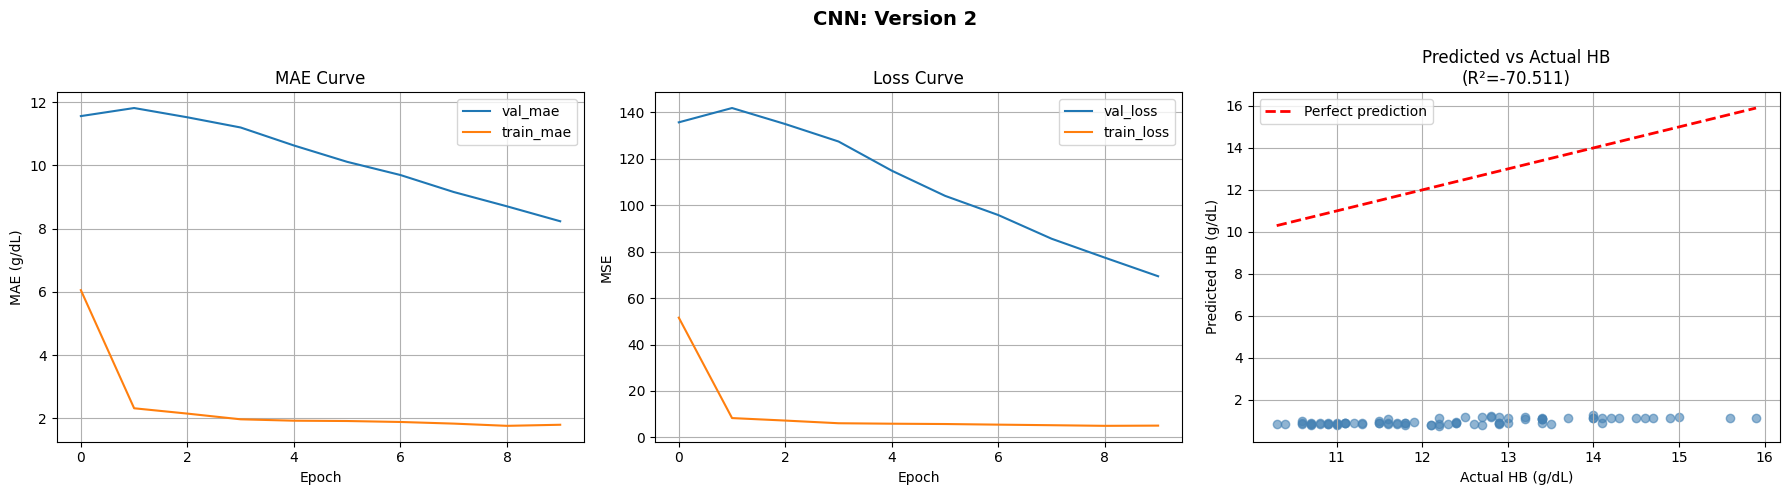

In [26]:
evaluate_regression_model("CNN: Version 2", model_2_REG,  history_2_REG)

## CNN3

In [16]:
model_3_REG = build_models(backbone="cnn3",mode="regression")

In [17]:
model_3_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_3_REG = model_3_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 716s 10s/step - loss: 33.6842 - mae: 4.5768 - rmse: 5.7985 - val_loss: 55.3079 - val_mae: 7.2873 - val_rmse: 7.4328 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 522s 9s/step - loss: 9.4605 - mae: 2.4580 - rmse: 3.0658 - val_loss: 65.8790 - val_mae: 7.9858 - val_rmse: 8.1128 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 507s 9s/step - loss: 8.2266 - mae: 2.2736 - rmse: 2.8575 - val_loss: 57.6543 - val_mae: 7.4667 - val_rmse: 7.5890 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 705s 12s/step - loss: 6.6830 - mae: 2.0387 - rmse: 2.5733 - val_loss: 53.3445 - val_mae: 7.1985 - val_rmse: 7.2995 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 428s 7s/step - loss: 6.4382 - mae: 2.0318 - rmse: 2.5253 - val_loss: 39.2904 - val_mae: 6.1675 - val_rmse: 6.2633 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 460s 8s/step - loss: 5.7588 - mae: 1.9027 - rmse: 2.3

CNN: Version 3
Metric                 Validation       Test
Loss (MSE)                 1.5465     1.1856
MAE                        0.9470     0.7919
RMSE                       1.2192     1.0609
R²                                    0.3875


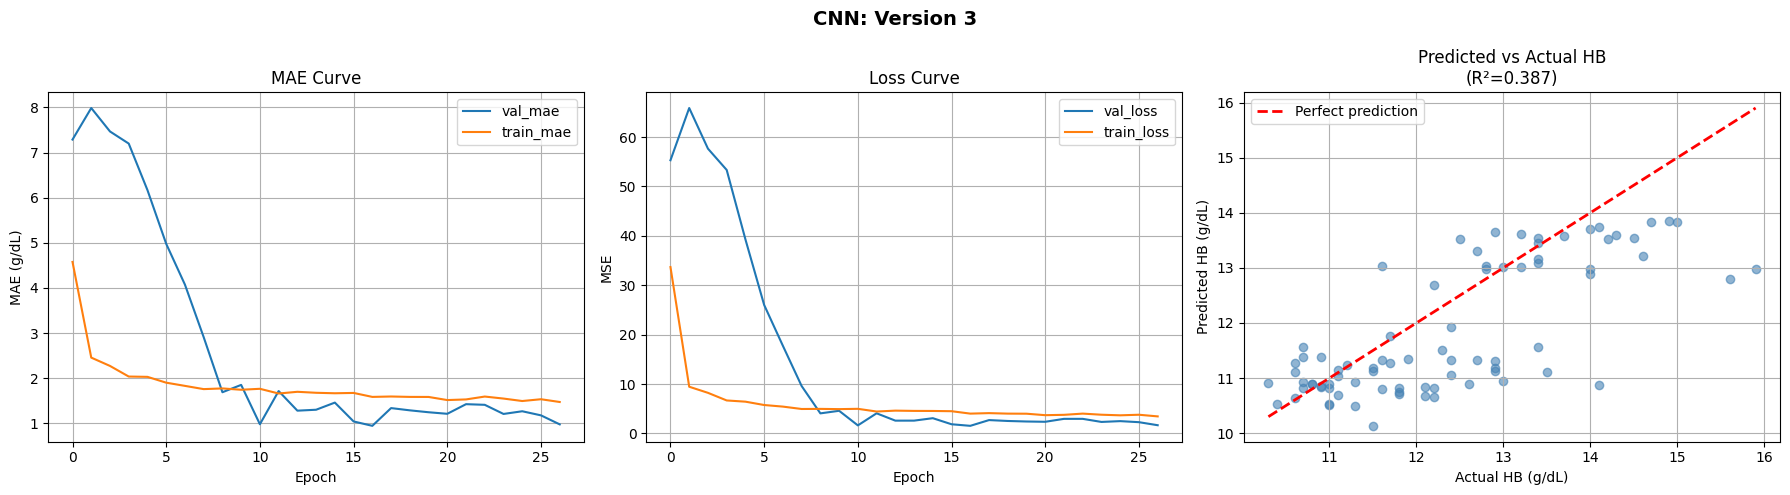

In [18]:
evaluate_regression_model("CNN: Version 3", model_3_REG,  history_3_REG)

## CNN_4

In [19]:
model_4_REG = build_models(backbone="cnn4",mode="regression")

In [20]:
model_4_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_4_REG = model_4_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 23.6456 - mae: 3.7262 - rmse: 4.8564 - val_loss: 2.1282 - val_mae: 1.2036 - val_rmse: 1.4380 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 7.9278 - mae: 2.2414 - rmse: 2.8050 - val_loss: 1.5784 - val_mae: 0.9952 - val_rmse: 1.2324 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 6.6794 - mae: 2.0513 - rmse: 2.5730 - val_loss: 1.5583 - val_mae: 0.9593 - val_rmse: 1.2246 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - loss: 6.3569 - mae: 2.0268 - rmse: 2.5097 - val_loss: 1.5209 - val_mae: 0.9564 - val_rmse: 1.2095 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - loss: 5.4126 - mae: 1.8464 - rmse: 2.3140 - val_loss: 1.2780 - val_mae: 0.8676 - val_rmse: 1.1048 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - loss: 5.5315 - mae: 1.8539 - rmse: 2.3397 - val_lo

CNN: Version 4
Metric                 Validation       Test
Loss (MSE)                 1.0365     0.9263
MAE                        0.7685     0.7615
RMSE                       0.9901     0.9328
R²                                    0.5264


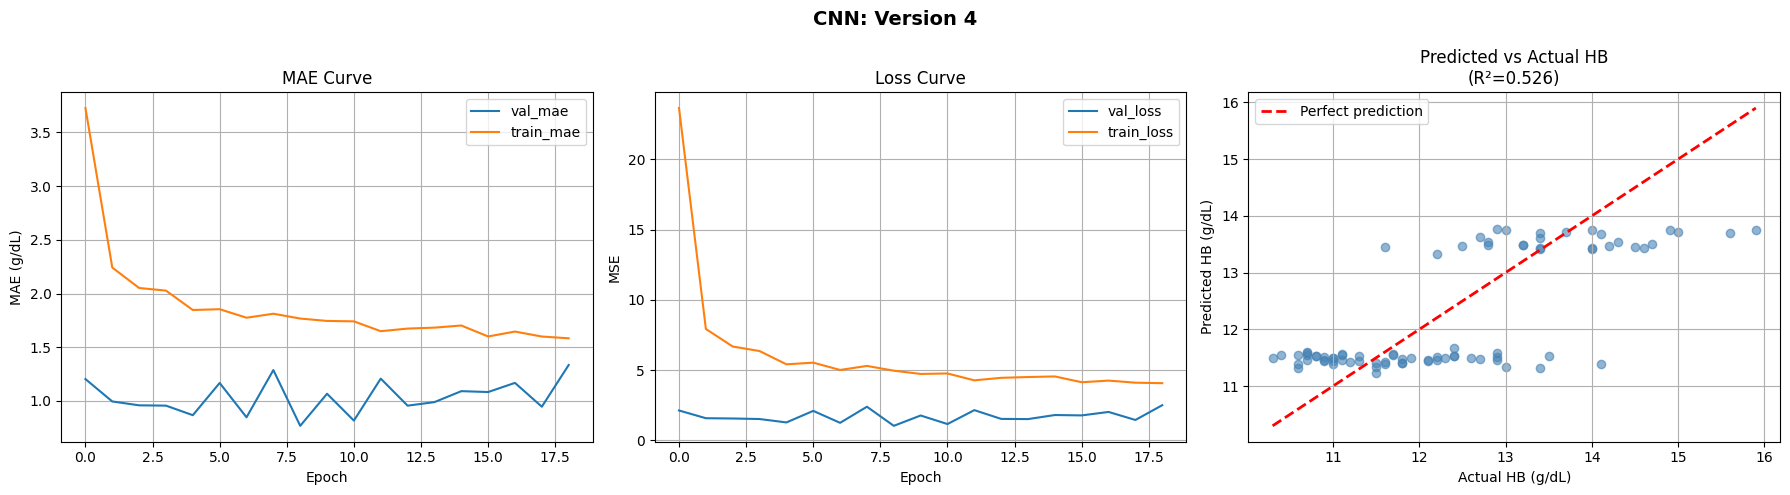

In [21]:
evaluate_regression_model("CNN: Version 4", model_4_REG,  history_4_REG)

## CNN_5

In [22]:
model_5_REG = build_models(backbone="cnn5",mode="regression")

In [23]:
model_5_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_5_REG = model_5_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 401s 6s/step - loss: 22.3370 - mae: 3.6637 - rmse: 4.7198 - val_loss: 2.6952 - val_mae: 1.2243 - val_rmse: 1.6233 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 347s 6s/step - loss: 8.3991 - mae: 2.3118 - rmse: 2.8878 - val_loss: 1.6195 - val_mae: 1.0116 - val_rmse: 1.2492 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 355s 6s/step - loss: 7.5834 - mae: 2.2145 - rmse: 2.7432 - val_loss: 2.4675 - val_mae: 1.2391 - val_rmse: 1.5523 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - loss: 6.2064 - mae: 1.9990 - rmse: 2.4797 - val_loss: 1.2711 - val_mae: 0.8444 - val_rmse: 1.1017 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 624s 11s/step - loss: 6.0799 - mae: 1.9587 - rmse: 2.4541 - val_loss: 1.8897 - val_mae: 1.0762 - val_rmse: 1.3539 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1404s 24s/step - loss: 5.3819 - mae: 1.8571 - rmse: 2.3076 

CNN: Version 5
Metric                 Validation       Test
Loss (MSE)                 2.6952     1.9041
MAE                        1.2243     1.0891
RMSE                       1.6233     1.3580
R²                                   -0.0036


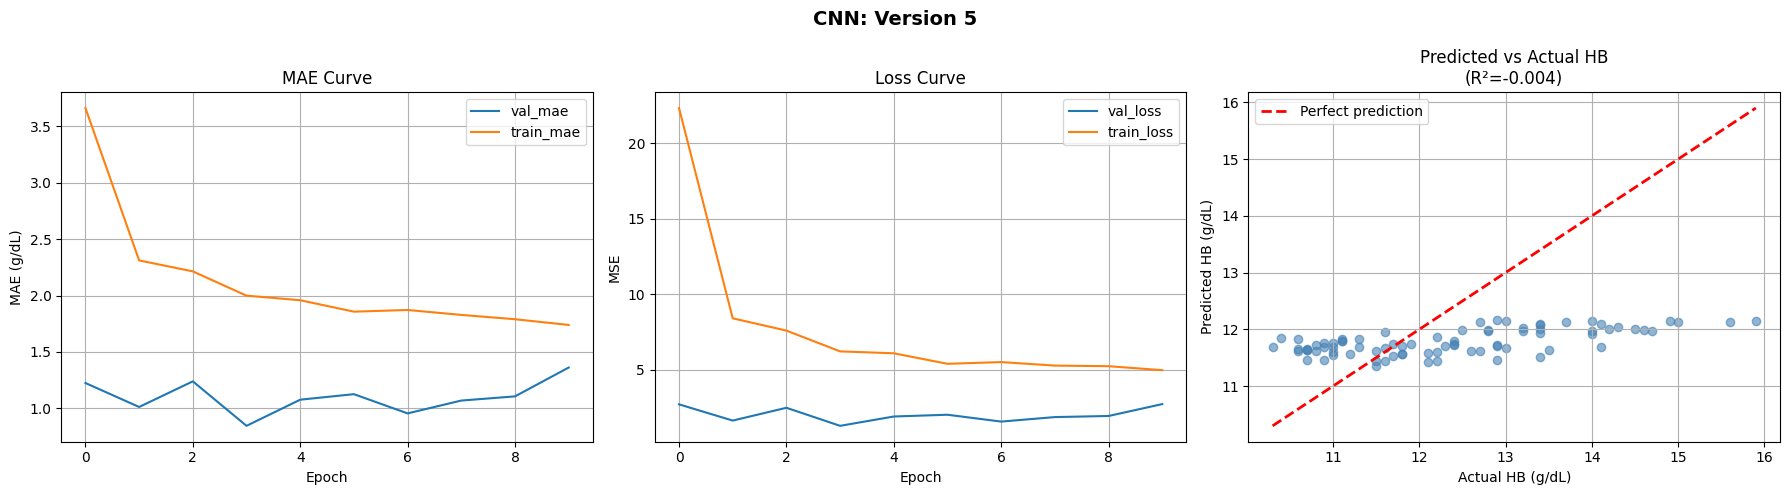

In [24]:
evaluate_regression_model("CNN: Version 5", model_5_REG,  history_5_REG)

## MobileNetV2

In [ ]:
model_6_REG = build_models(backbone="mobilenetv2",mode="regression")

In [ ]:
model_6_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_6_REG = model_6_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 107s 999ms/step - loss: 6.3032 - mae: 1.9763 - rmse: 2.4985 - val_loss: 7.8284 - val_mae: 2.5301 - val_rmse: 2.7872 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 731ms/step - loss: 5.6245 - mae: 1.8651 - rmse: 2.3591 - val_loss: 12.8410 - val_mae: 3.3945 - val_rmse: 3.5752 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 740ms/step - loss: 4.9394 - mae: 1.7723 - rmse: 2.2093 - val_loss: 17.4170 - val_mae: 4.0075 - val_rmse: 4.1664 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 46s 791ms/step - loss: 4.9734 - mae: 1.7702 - rmse: 2.2171 - val_loss: 19.4559 - val_mae: 4.2786 - val_rmse: 4.4044 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 721ms/step - loss: 4.4811 - mae: 1.6705 - rmse: 2.1033 - val_loss: 12.3230 - val_mae: 3.3286 - val_rmse: 3.5023 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 735ms/step - loss: 4.4460 - mae: 1.6825 - 

MobileNet
Metric                 Validation       Test
Loss (MSE)                 7.8284     6.1649
MAE                        2.5301     2.2754
RMSE                       2.7872     2.4709
R²                                   -2.3225


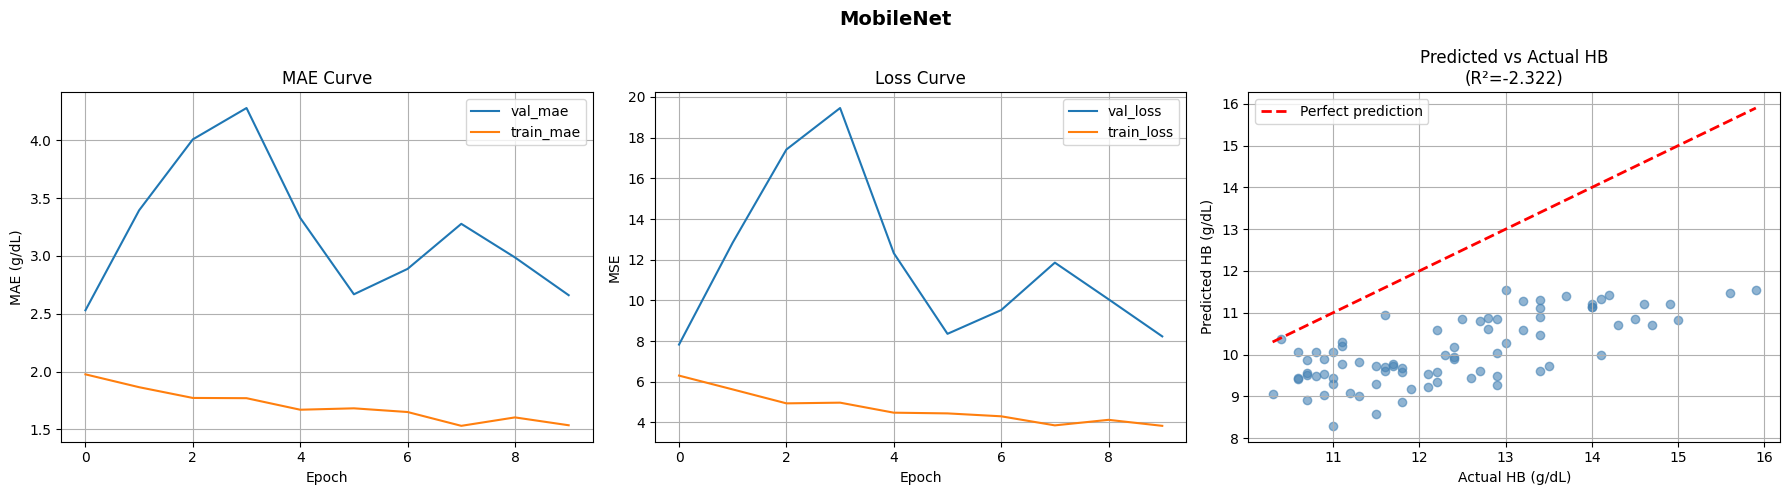

In [ ]:
evaluate_regression_model("MobileNet", model_6_REG,  history_6_REG)

## EfficientNetB0

In [ ]:
model_7_REG = build_models(backbone="efficientnetb0",mode="regression")

In [ ]:
model_7_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4) ,
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

In [ ]:
history_7_REG = model_7_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - loss: 69.7836 - mae: 7.2243 - rmse: 8.3500 - val_loss: 4.2288 - val_mae: 1.5170 - val_rmse: 2.0413 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 11.4050 - mae: 2.6972 - rmse: 3.3680 - val_loss: 3.7390 - val_mae: 1.4391 - val_rmse: 1.9177 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 9.6396 - mae: 2.4894 - rmse: 3.0948 - val_loss: 2.8888 - val_mae: 1.2679 - val_rmse: 1.6815 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 8.0950 - mae: 2.2765 - rmse: 2.8343 - val_loss: 2.2353 - val_mae: 1.1265 - val_rmse: 1.4744 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - loss: 7.3291 - mae: 2.1509 - rmse: 2.6959 - val_loss: 1.5571 - val_mae: 0.9575 - val_rmse: 1.2230 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 7.0865 - mae: 2.1067 - rmse: 2.6505 - val_l

EfficientNetB0
Metric                 Validation       Test
Loss (MSE)                 1.0176     0.9354
MAE                        0.7794     0.7777
RMSE                       0.9780     0.9350
R²                                    0.5242


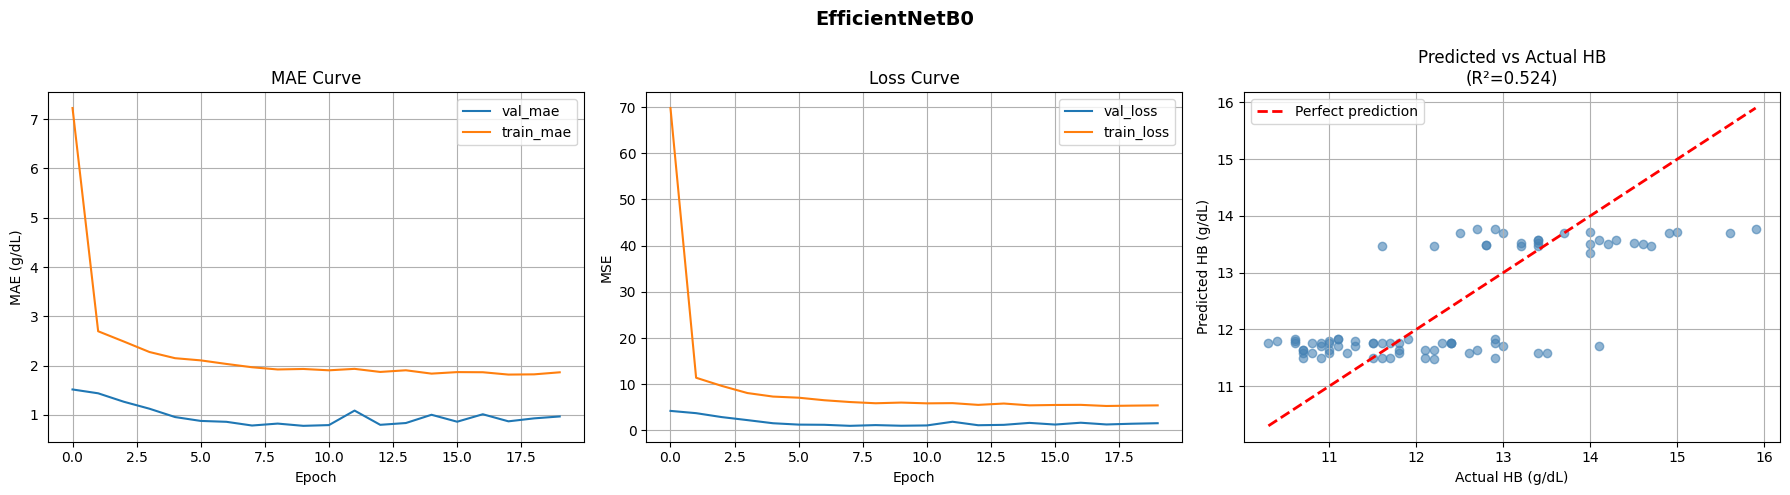

In [ ]:
evaluate_regression_model("EfficientNetB0", model_7_REG,  history_7_REG)

## DenseNet121

In [ ]:
model_8_REG = build_models(backbone="densenet121",mode="regression")

In [ ]:
model_8_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_8_REG = model_8_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 366s 5s/step - loss: 43.6324 - mae: 5.3286 - rmse: 6.6008 - val_loss: 15.6496 - val_mae: 3.5980 - val_rmse: 3.9481 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 243s 4s/step - loss: 9.2664 - mae: 2.4180 - rmse: 3.0339 - val_loss: 3.5456 - val_mae: 1.4462 - val_rmse: 1.8665 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 243s 4s/step - loss: 7.5391 - mae: 2.1785 - rmse: 2.7345 - val_loss: 2.1187 - val_mae: 1.1064 - val_rmse: 1.4343 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 241s 4s/step - loss: 6.7527 - mae: 2.0798 - rmse: 2.5867 - val_loss: 1.9428 - val_mae: 1.0759 - val_rmse: 1.3716 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - loss: 6.1305 - mae: 1.9762 - rmse: 2.4635 - val_loss: 1.3430 - val_mae: 0.8953 - val_rmse: 1.1321 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 244s 4s/step - loss: 5.4311 - mae: 1.8503 - rmse: 2.3173 - 

DenseNet
Metric                 Validation       Test
Loss (MSE)                15.6496    12.9424
MAE                        3.5980     3.3110
RMSE                       3.9481     3.5890
R²                                   -6.0097


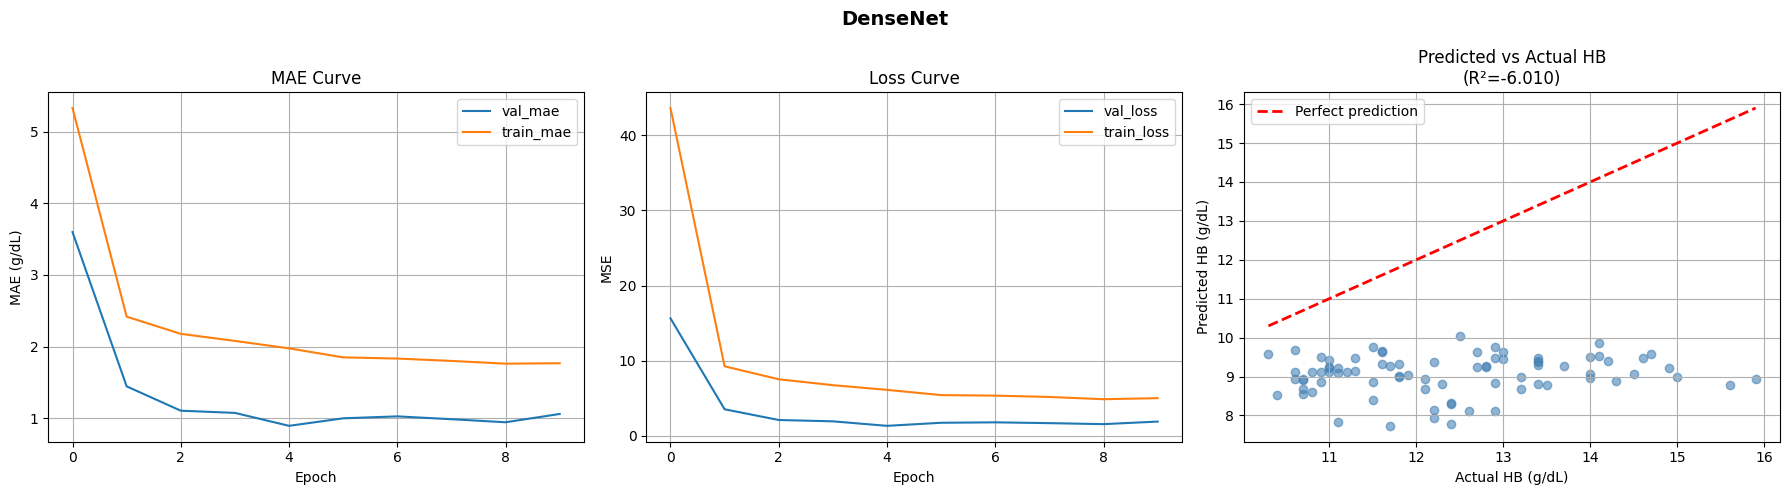

In [ ]:
evaluate_regression_model("DenseNet", model_8_REG,  history_8_REG)

## DenseNet169

In [25]:
model_9_REG = build_models(backbone="densenet169",mode="regression")

In [26]:
model_9_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_9_REG = model_9_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 433s 5s/step - loss: 32.3601 - mae: 4.4662 - rmse: 5.6832 - val_loss: 13.0944 - val_mae: 3.2505 - val_rmse: 3.6101 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 227s 4s/step - loss: 9.3330 - mae: 2.3895 - rmse: 3.0449 - val_loss: 2.8396 - val_mae: 1.2885 - val_rmse: 1.6667 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - loss: 7.4888 - mae: 2.1727 - rmse: 2.7253 - val_loss: 1.8700 - val_mae: 1.0665 - val_rmse: 1.3448 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - loss: 6.7693 - mae: 2.0711 - rmse: 2.5900 - val_loss: 1.6572 - val_mae: 1.0161 - val_rmse: 1.2633 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - loss: 5.9542 - mae: 1.9412 - rmse: 2.4275 - val_loss: 1.1652 - val_mae: 0.8344 - val_rmse: 1.0507 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 287s 5s/step - loss: 5.4357 - mae: 1.8302 - rmse: 2.3183 - 

DenseNet169
Metric                 Validation       Test
Loss (MSE)                13.0944    11.7776
MAE                        3.2505     3.1306
RMSE                       3.6101     3.4228
R²                                   -5.3759


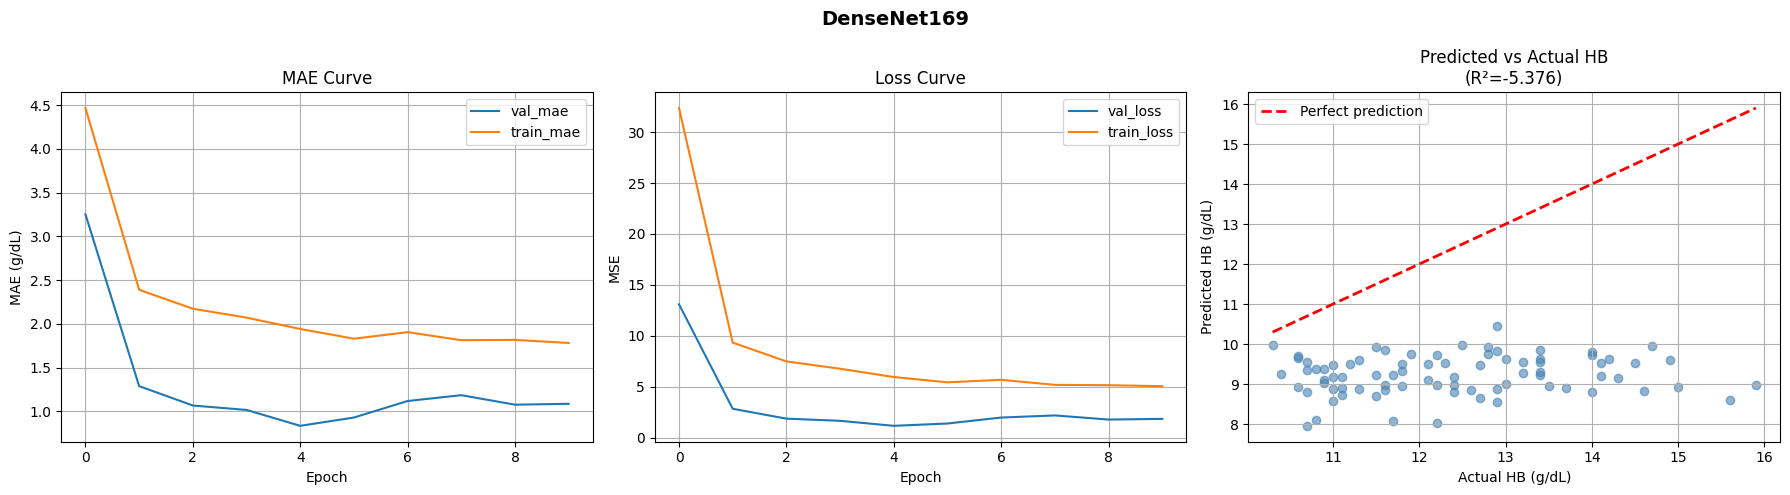

In [27]:
evaluate_regression_model("DenseNet169", model_9_REG,  history_9_REG)

## ResNet50

In [28]:
model_10_REG = build_models(backbone="resnet50",mode="regression")

In [29]:
model_10_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_10_REG = model_10_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - loss: 20.7067 - mae: 3.5294 - rmse: 4.5437 - val_loss: 9.6953 - val_mae: 2.8050 - val_rmse: 3.1038 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 221s 4s/step - loss: 7.3973 - mae: 2.1524 - rmse: 2.7084 - val_loss: 4.2446 - val_mae: 1.7305 - val_rmse: 2.0452 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - loss: 6.6486 - mae: 2.0598 - rmse: 2.5665 - val_loss: 1.5427 - val_mae: 0.9726 - val_rmse: 1.2170 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - loss: 5.8815 - mae: 1.9190 - rmse: 2.4125 - val_loss: 1.9634 - val_mae: 1.0767 - val_rmse: 1.3792 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 216s 4s/step - loss: 5.0701 - mae: 1.7846 - rmse: 2.2380 - val_loss: 4.6064 - val_mae: 1.8484 - val_rmse: 2.1319 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - loss: 4.8024 - mae: 1.7276 - rmse: 2.1774 - v

ResNet50
Metric                 Validation       Test
Loss (MSE)                 9.6953     8.7943
MAE                        2.8050     2.7004
RMSE                       3.1038     2.9551
R²                                   -3.7523


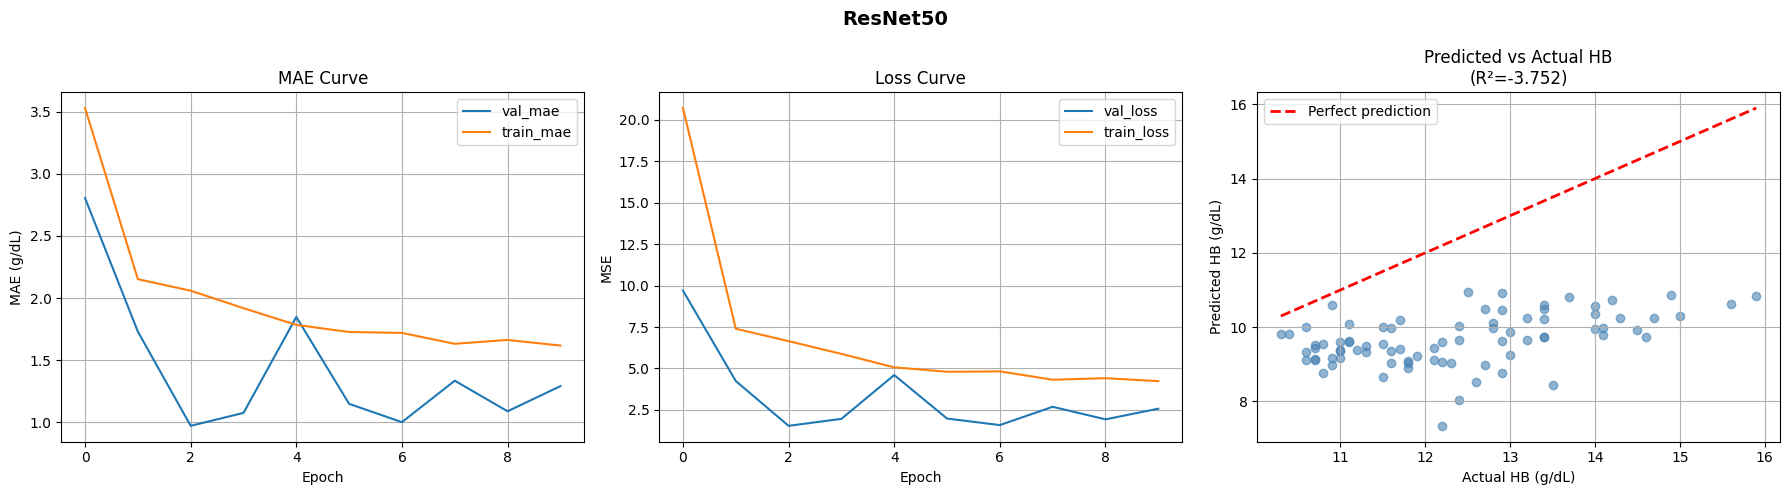

In [30]:
evaluate_regression_model("ResNet50", model_10_REG,  history_10_REG)

# Comparision Table

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

all_models = [
    ("CNN1",           model_1_REG),
    ("CNN2",           model_2_REG),
    ("MobileNetV2",    model_3_REG),
    ("EfficientNetB0", model_4_REG),
    ("DenseNet121",    model_5_REG),
]

results = []
for name, model in all_models:
    y_hb_pred_val  = model.predict([X_palm_val,  X_nail_val,  X_meta_val],  verbose=0).ravel()
    y_hb_pred_test = model.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).ravel()

    results.append({
        "Model"    : name,
        "Val MAE"  : round(mean_absolute_error(y_hb_val,  y_hb_pred_val),  4),
        "Test MAE" : round(mean_absolute_error(y_hb_test, y_hb_pred_test), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_hb_test, y_hb_pred_test)), 4),
        "Test R²"  : round(r2_score(y_hb_test, y_hb_pred_test), 4),
    })

df = pd.DataFrame(results).sort_values("Val MAE", ascending=True).reset_index(drop=True)
df.index += 1

print(f"\n{'='*65}")
print(f"  FINAL REGRESSION MODEL COMPARISON")
print(f"{'='*65}")
print(df.to_string())
print(f"\n✅ Best Backbone (by Val MAE): {df.iloc[0]['Model']} (Val MAE = {df.iloc[0]['Val MAE']}, Test MAE = {df.iloc[0]['Test MAE']})")


  FINAL REGRESSION MODEL COMPARISON
            Model  Val MAE  Test MAE  Test RMSE  Test R²
1  EfficientNetB0   0.7794    0.7777     0.9350   0.5242
2            CNN1   0.8336    0.7576     0.9599   0.4986
3     MobileNetV2   2.5301    2.2754     2.4709  -2.3225
4     DenseNet121   3.5980    3.3110     3.5890  -6.0097
5            CNN2  11.5545   11.3931    11.4632 -70.5114

✅ Best Backbone (by Val MAE): EfficientNetB0 (Val MAE = 0.7794, Test MAE = 0.7777)


In [ ]:
model_4_REG.save("Regression_Models/EfficientNetB0_Regression.keras")
model_1_REG.save("Regression_Models/CNN1_Regression.keras")

# Other Experiments

## KFOLD - EfficientNetB0

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

N_SPLITS            = 5
skf                 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
train_subject_ids   = subject_ids[train_idx]
unique_train_subj   = np.unique(train_subject_ids)
unique_train_labels = np.array([y_label[train_idx][train_subject_ids == s][0]
                                 for s in unique_train_subj])
fold_results = []

In [17]:
for fold, (tr_subj_idx, vl_subj_idx) in enumerate(
    skf.split(unique_train_subj, unique_train_labels)
):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1}/{N_SPLITS}")
    print(f"{'='*50}")

    tr_subj = unique_train_subj[tr_subj_idx]
    vl_subj = unique_train_subj[vl_subj_idx]
    tr_idx  = np.where(np.isin(train_subject_ids, tr_subj))[0]
    vl_idx  = np.where(np.isin(train_subject_ids, vl_subj))[0]

    X_palm_tr = X_palm_train[tr_idx];  X_palm_vl = X_palm_train[vl_idx]
    X_nail_tr = X_nail_train[tr_idx];  X_nail_vl = X_nail_train[vl_idx]
    X_meta_tr = X_meta_train[tr_idx];  X_meta_vl = X_meta_train[vl_idx]
    y_hb_tr   = y_hb_train[tr_idx];    y_hb_vl   = y_hb_train[vl_idx]

    # ── Augment fold training data ───────────────────────────────
    X_palm_tr, X_nail_tr, X_meta_tr, y_hb_tr = augment_training_set(
        X_palm_tr, X_nail_tr, X_meta_tr, y_hb_tr
    )
    print(f"Train size : {len(y_hb_tr)} | Val size: {len(y_hb_vl)}")
    print(f"HB range   : {y_hb_tr.min():.1f} — {y_hb_tr.max():.1f} g/dL")

    # ── Model ────────────────────────────────────────────────────
    model_6_REG = build_models(backbone="efficientnetb0", mode="regression")
    model_6_REG.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-6) ,
        loss      = "mse",
        metrics   = [
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )

    fold_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mae", patience=10,
            mode="min", restore_best_weights=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae", patience=5,
            mode="min", factor=0.5, min_lr=1e-6, verbose=0
        )
    ]

    history_6_REG =  model_6_REG.fit(
        x               = [X_palm_tr, X_nail_tr, X_meta_tr],
        y               = y_hb_tr,
        validation_data = ([X_palm_vl, X_nail_vl, X_meta_vl], y_hb_vl),
        epochs=100, batch_size=32,
        callbacks=fold_callbacks, verbose=1
    )

    # ── Evaluate fold ────────────────────────────────────────────
    y_hb_pred =  model_6_REG.predict([X_palm_vl, X_nail_vl, X_meta_vl], verbose=0).ravel()
    mae       = mean_absolute_error(y_hb_vl,  y_hb_pred)
    rmse      = np.sqrt(mean_squared_error(y_hb_vl, y_hb_pred))
    r2        = r2_score(y_hb_vl, y_hb_pred)

    print(f"\nFold {fold+1} → MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

    fold_results.append({
        "fold"   : fold + 1,
        "mae"    : mae,
        "rmse"   : rmse,
        "r2"     : r2,
        "model"  : model_6_REG,
        "history": history_6_REG
    })


FOLD 1/5
Train size : 1470 | Val size: 74
HB range   : 8.9 — 17.0 g/dL

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - loss: 113.1240 - mae: 10.4414 - rmse: 10.6331 - val_loss: 80.9813 - val_mae: 8.8581 - val_rmse: 8.9955 - learning_rate: 1.0000e-05
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - loss: 53.6051 - mae: 6.8765 - rmse: 7.3173 - val_loss: 24.3791 - val_mae: 4.6710 - val_rmse: 4.9313 - learning_rate: 1.0000e-05
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - loss: 21.1464 - mae: 3.8551 - rmse: 4.5918 - val_loss: 4.7141 - val_mae: 1.6295 - val_rmse: 2.1569 - learning_rate: 1.0000e-05
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - loss: 13.0721 - mae: 2.8998 - rmse: 3.6070 - val_loss: 2.4600 - val_mae: 1.2474 - val_rmse: 1.5486 - learning_rate: 1.0000e-05
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 192s 3s/step - loss: 12.1461 - mae: 2.8147 - rmse: 3.4763 - val_loss: 2.4775 - val_mae: 1.2932 - val_rmse: 1.5543 - learning_rate: 1.0000e-05
Epoch 6/100
46/46 ━


K-FOLD SUMMARY — EfficientNetB0 Regression
Fold 1 → MAE: 0.8249 | RMSE: 0.9968 | R²: 0.4445
Fold 2 → MAE: 0.6679 | RMSE: 0.8274 | R²: 0.5060
Fold 3 → MAE: 0.8043 | RMSE: 1.0129 | R²: 0.5169
Fold 4 → MAE: 0.8244 | RMSE: 1.0670 | R²: 0.3301
Fold 5 → MAE: 0.7667 | RMSE: 0.9953 | R²: 0.5649

Mean MAE  : 0.7776 ± 0.0588
Mean RMSE : 0.9799 ± 0.0806
Mean R²   : 0.4725 ± 0.0809

✅ Best Fold: 2 (MAE=0.6679)

FINAL TEST RESULTS — EfficientNetB0 Regression
MAE  : 0.7955 g/dL
RMSE : 0.9984 g/dL
R²   : 0.4576


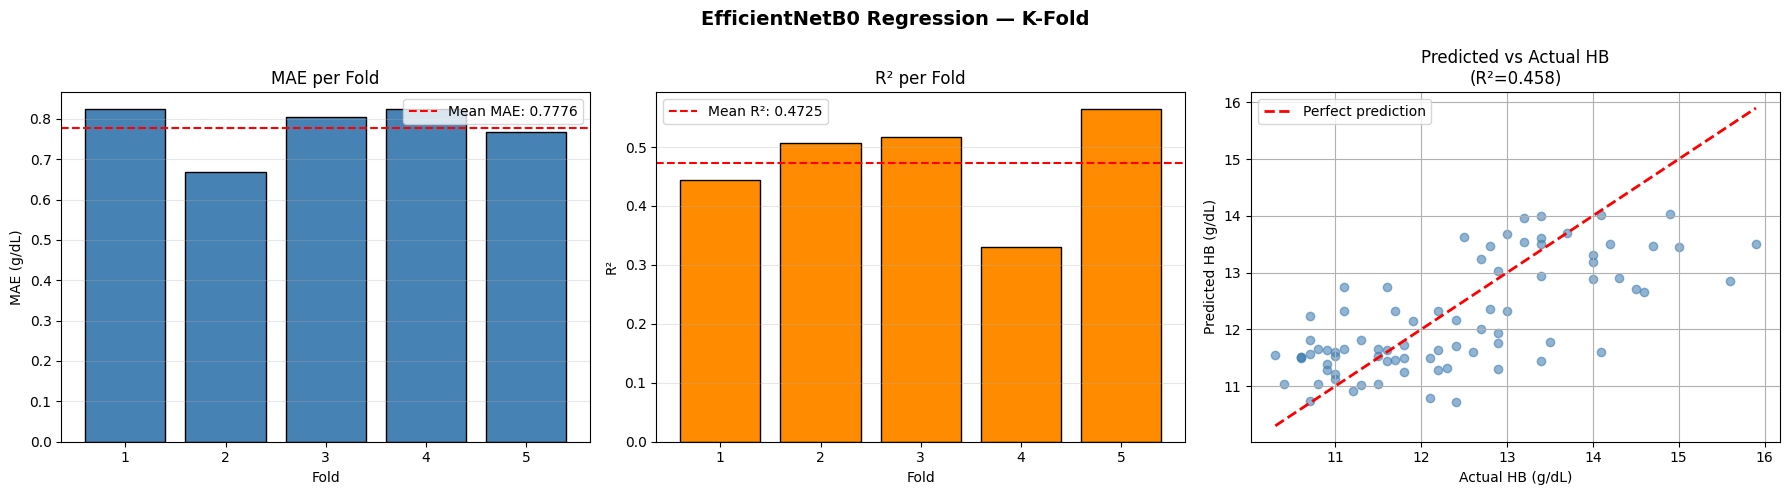

In [18]:
# ── K-Fold Summary ───────────────────────────────────────────────
print(f"\n{'='*50}")
print("K-FOLD SUMMARY — EfficientNetB0 Regression")
print(f"{'='*50}")

maes  = [r["mae"]  for r in fold_results]
rmses = [r["rmse"] for r in fold_results]
r2s   = [r["r2"]   for r in fold_results]

for r in fold_results:
    print(f"Fold {r['fold']} → MAE: {r['mae']:.4f} | RMSE: {r['rmse']:.4f} | R²: {r['r2']:.4f}")

print(f"\nMean MAE  : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"Mean RMSE : {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
print(f"Mean R²   : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")

# ── Best fold ────────────────────────────────────────────────────
best_fold  = fold_results[np.argmin(maes)]
best_model = best_fold["model"]
print(f"\n✅ Best Fold: {best_fold['fold']} (MAE={best_fold['mae']:.4f})")

# ── Test set evaluation ──────────────────────────────────────────
y_hb_pred_test = best_model.predict(
    [X_palm_test, X_nail_test, X_meta_test], verbose=0
).ravel()

print(f"\n{'='*50}")
print("FINAL TEST RESULTS — EfficientNetB0 Regression")
print(f"{'='*50}")
print(f"MAE  : {mean_absolute_error(y_hb_test, y_hb_pred_test):.4f} g/dL")
print(f"RMSE : {np.sqrt(mean_squared_error(y_hb_test, y_hb_pred_test)):.4f} g/dL")
print(f"R²   : {r2_score(y_hb_test, y_hb_pred_test):.4f}")

# ── Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EfficientNetB0 Regression — K-Fold", fontsize=14, fontweight="bold")

# Plot 1 - MAE per fold
axes[0].bar([r["fold"] for r in fold_results], maes, color="steelblue", edgecolor="black")
axes[0].axhline(np.mean(maes), color="red", linestyle="--", label=f"Mean MAE: {np.mean(maes):.4f}")
axes[0].set_title("MAE per Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("MAE (g/dL)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2 - R² per fold
axes[1].bar([r["fold"] for r in fold_results], r2s, color="darkorange", edgecolor="black")
axes[1].axhline(np.mean(r2s), color="red", linestyle="--", label=f"Mean R²: {np.mean(r2s):.4f}")
axes[1].set_title("R² per Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R²")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Plot 3 - Predicted vs Actual on test set
axes[2].scatter(y_hb_test, y_hb_pred_test, alpha=0.6, color="steelblue")
axes[2].plot([y_hb_test.min(), y_hb_test.max()],
             [y_hb_test.min(), y_hb_test.max()],
             "r--", lw=2, label="Perfect prediction")
axes[2].set_title(f"Predicted vs Actual HB\n(R²={r2_score(y_hb_test, y_hb_pred_test):.3f})")
axes[2].set_xlabel("Actual HB (g/dL)")
axes[2].set_ylabel("Predicted HB (g/dL)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## EfficientNetB0 trained with normalized HB

In [ ]:
hb_mean = y_hb_train.mean()
hb_std  = y_hb_train.std()

y_hb_train_norm = (y_hb_train - hb_mean) / hb_std
y_hb_val_norm   = (y_hb_val   - hb_mean) / hb_std
y_hb_test_norm  = (y_hb_test  - hb_mean) / hb_std

print(f"HB mean : {hb_mean:.4f} | HB std : {hb_std:.4f}")

HB mean : 12.2889 | HB std : 1.3660


In [36]:
history_reg = model_4_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train_norm,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val_norm),
    epochs=100, batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - loss: 0.8094 - mae: 1.1605 - rmse: 1.4360 - val_loss: 0.6895 - val_mae: 1.0650 - val_rmse: 1.2052 - learning_rate: 1.0000e-06
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.7222 - mae: 1.0709 - rmse: 1.3195 - val_loss: 0.6831 - val_mae: 1.0473 - val_rmse: 1.2224 - learning_rate: 1.0000e-06
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.6971 - mae: 1.0365 - rmse: 1.2924 - val_loss: 0.6767 - val_mae: 1.0277 - val_rmse: 1.2354 - learning_rate: 1.0000e-06
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - loss: 0.6469 - mae: 0.9846 - rmse: 1.2246 - val_loss: 0.6506 - val_mae: 0.9838 - val_rmse: 1.2186 - learning_rate: 1.0000e-06
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.6412 - mae: 0.9732 - rmse: 1.2210 - val_loss: 0.6277 - val_mae: 0.9476 - val_rmse: 1.2038 - learning_rate: 1.0000e-06
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.6043 - mae: 0.9323 - rmse: 1.1743 - val_los

MAE  : 0.7986 g/dL
RMSE : 0.9801 g/dL
R²   : 0.4772


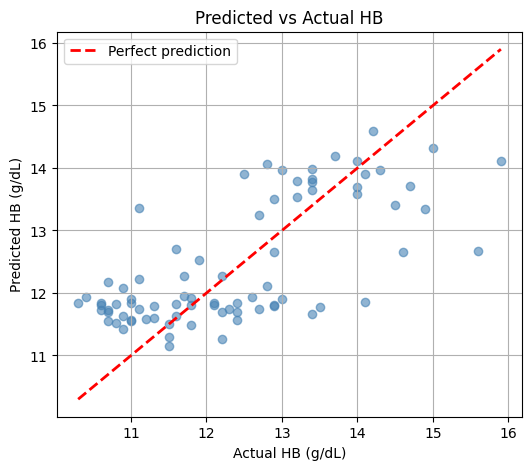

In [37]:
# predict and denormalize
y_pred_norm   = model_4_REG.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).ravel()
y_pred_actual = (y_pred_norm * hb_std) + hb_mean  # ← back to g/dL

# evaluate on actual values
print(f"MAE  : {mean_absolute_error(y_hb_test, y_pred_actual):.4f} g/dL")
print(f"RMSE : {np.sqrt(mean_squared_error(y_hb_test, y_pred_actual)):.4f} g/dL")
print(f"R²   : {r2_score(y_hb_test, y_pred_actual):.4f}")

# scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(y_hb_test, y_pred_actual, alpha=0.6, color="steelblue")
plt.plot([y_hb_test.min(), y_hb_test.max()],
         [y_hb_test.min(), y_hb_test.max()],
         "r--", lw=2, label="Perfect prediction")
plt.title(f"Predicted vs Actual HB")
plt.xlabel("Actual HB (g/dL)")
plt.ylabel("Predicted HB (g/dL)")
plt.legend()
plt.grid(True)
plt.show()